In [31]:
# Анализ влияния признаков на цену бриллианта
## 1. Импорт библиотек и загрузка данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем датасет
df = pd.read_csv('/content/drive/MyDrive/Data/13.10.2025_К 6 ЗАДАНИЮ_diamonds.csv')

# Смотрим первые строки
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [35]:
## 2. Первичный анализ данных
df.info()
df.describe()
### Смотрим, есть ли пропущенные значения и какие признаки числовые, а какие категориальные (cut, color, clarity).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Значения x, y, z - есть = 0. Что не возможно.

In [58]:
# Посмотрим на строки с 0-ми размерами
df.loc[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,4,4,2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,4,3,1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,4,4,2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,4,5,2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,2,4,1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,5,5,2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,3,3,4,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,5,4,4,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,1,4,5,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,4,3,2,59.4,61.0,12631,8.49,8.45,0.0


In [59]:
len(df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)])

19

In [60]:
# Удалим их
df = df[(df[['x', 'y', 'z']] != 0).all(axis = 1)]

In [61]:
len(df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)])

0

In [62]:
## 3. Проверим пропуски и дубликаты
df.isnull().sum(), df.duplicated().sum()

(carat      0
 cut        0
 color      0
 clarity    0
 depth      0
 table      0
 price      0
 x          0
 y          0
 z          0
 dtype: int64,
 np.int64(0))

In [63]:
## Пропусков нет. Удалим дубликаты
df = df.drop_duplicates()
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31
3,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,5,7,3,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,2,7,3,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,3,7,3,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,4,3,2,61.0,58.0,2757,6.15,6.12,3.74


In [46]:
## Преобразование категориальных признаков в числовые
# Кодируем категориальные признаки с учётом их порядка качества
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8}

df['cut'] = df['cut'].map(cut_map)
df['color'] = df['color'].map(color_map)
df['clarity'] = df['clarity'].map(clarity_map)

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31
3,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75


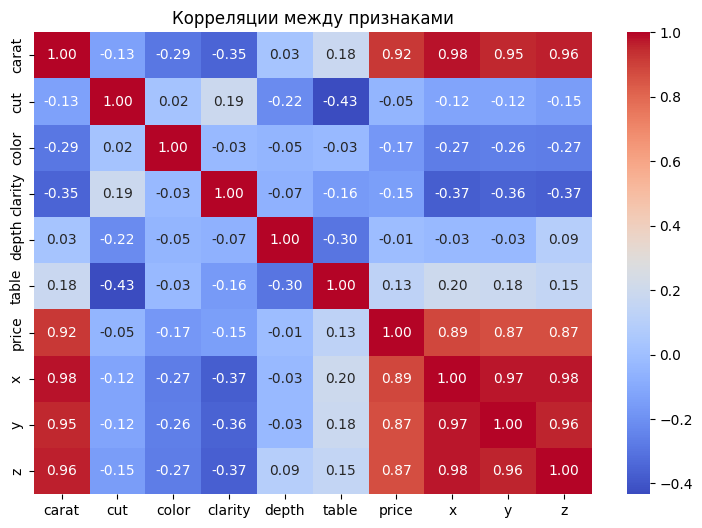

In [64]:
## 4. Корреляция числовых признаков с ценой
corr = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции между признаками')
plt.show()



Видим что наибольшая корреляция у цены с 'carat', 'x', 'y',
       'z'.Больше всего на цену влияет признак 'carat'.

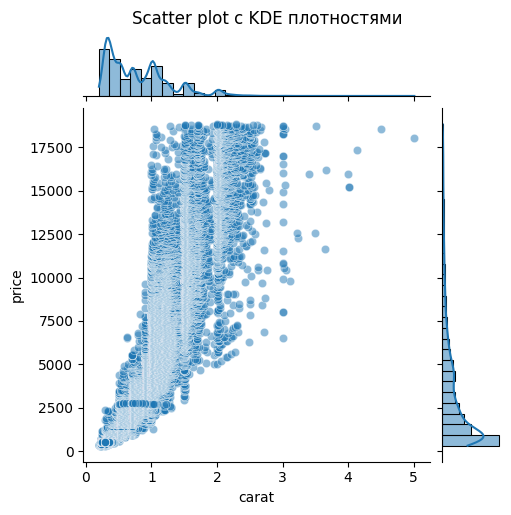

In [79]:
# Зависимость цены от ключевых признаков
# Влияние веса (carat) на цену


sns.jointplot(x='carat', y='price', data=df, kind='scatter', height=5,
              marginal_kws=dict(bins=30, kde=True, fill=True),
              joint_kws=dict(alpha=0.5))
plt.suptitle('Scatter plot с KDE плотностями', y=1.02)
plt.show()


Четкий восходящий тренд - с увеличением веса цена растет.

Практически экспоненциальная зависимость для основной массы данных.

Разброс увеличивается с ростом carat:

Для мелких камней (0-1 карат): плотное облако точек.

Для крупных камней (3-5 карат): широкий разброс цен.

Распределение сверху:

Резкий пик в области 0.2 карата.

Сильная скошенность вправо - немного крупных камней.

Дискретные пики на круглых значениях (1.0, 1.5, 2.0 карата).

Распределение price (справа):

Экстремальная скошенность - большинство камней недорогие.

Длинный правый хвост - редкие дорогие экземпляры.

Многомодальность - несколько ценовых кластеров.

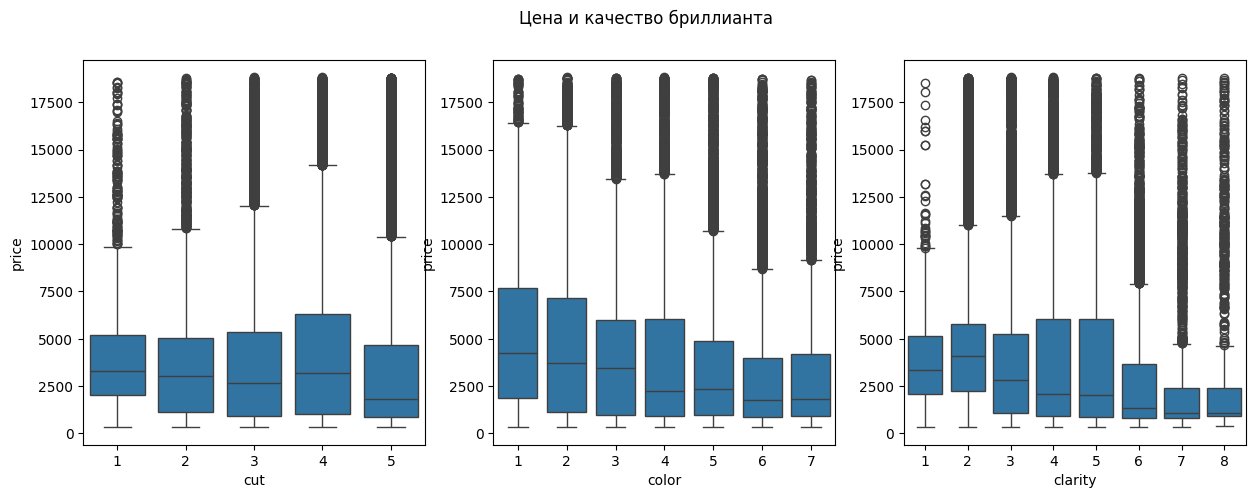

In [56]:
# Влияние категориальных признаков (уже числовых)
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(data=df, x='cut', y='price', ax=axes[0])
sns.boxplot(data=df, x='color', y='price', ax=axes[1])
sns.boxplot(data=df, x='clarity', y='price', ax=axes[2])
plt.suptitle('Цена и качество бриллианта')
plt.show()

Во всех категориях наблюдается огромный разброс цен.
Длинные верхние усы - наличие дорогих выбросов.
Скошенные распределения - медианы ближе к нижним квантилям.

Cut (качество огранки).
Неожиданная закономерность: худшие оценки cut (1) имеют более высокие медианные цены.
Cut 1 (худший): медиана ~$2800, много дорогих выбросов.
Cut 5 (лучший): медиана ~$2000, меньше вариаций.
Возможные причины:
Лучше ограненные камни могут быть меньшего веса при той же визуальной привлекательности.

Color (цвет).
Более четкий тренд: с увеличением цвета цена снижается.
Color 1: самая высокая медианная цена.
Color 7: самая низкая медианная цена.

Clarity (чистота).
Самый неоднозначный тренд.
Clarity 4-5 и 7-8 имеют схожие медианные цены.
Наибольшая вариабельность у clarity 3-5.
Минимальный разброс у clarity 7.


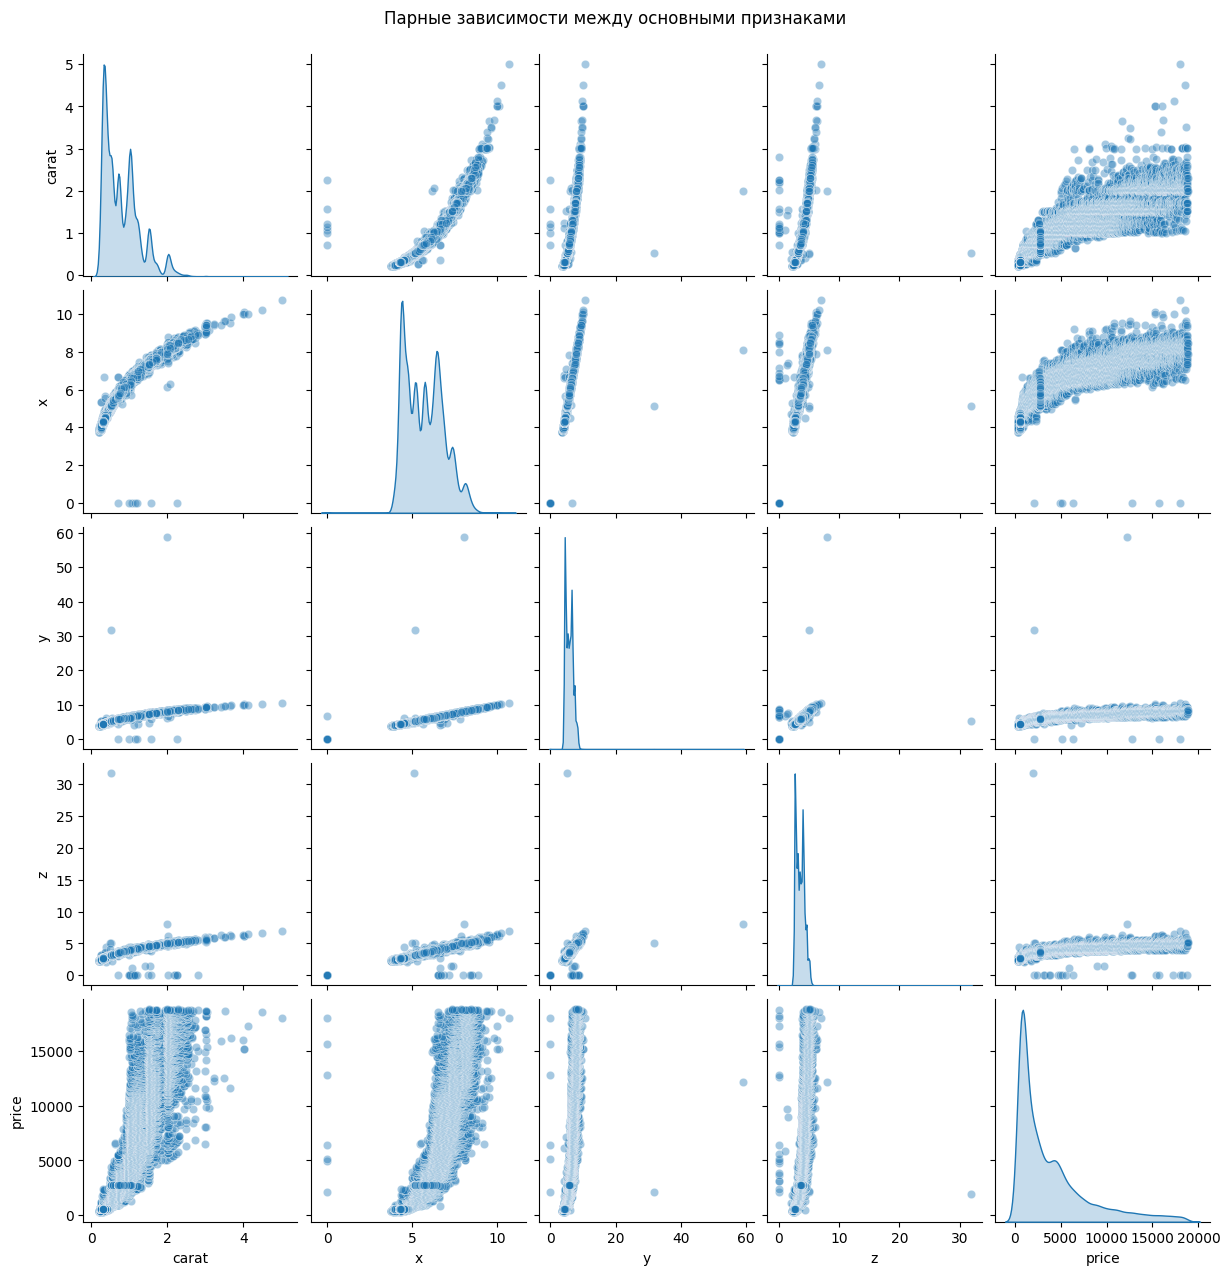

In [45]:
# Парные графики для основных числовых признаков
sns.pairplot(df[['carat', 'x', 'y', 'z', 'price']], diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle('Парные зависимости между основными признаками', y=1.02)
plt.show()



Основные наблюдения по распределениям:
1. Распределение carat (вес в каратах)
Сильно скошенное вправо распределение
Большинство камней имеют малый вес (0-2 карата)
Длинный правый хвост - немного очень крупных камней
Пик вокруг 0.3-0.8 карата

2. Распределение price (цена)
Экстремально скошенное распределение
Основная масса цен в диапазоне $0-$5,000
Очень длинный правый хвост - редкие дорогие экземпляры до $15,000+
Многомодальное распределение с несколькими пиками

3. Распределения x, y, z (размеры)
Все три измерения показывают похожие формы распределения
Скошенные вправо с концентрацией в меньших значениях
Сильная корреляция между размерами

